# Simple Linear Regression – Marketing ROI Analysis
**Goal:** Identify which marketing channel (TV, Radio, or Social Media) best predicts Sales, build a validated OLS regression model, and translate results into a clear budget recommendation.


## Step 1 – Imports & Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 – Load & Explore the Dataset

In [ ]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

print('--- Dataset Initial Info ---')
print(df.info())
print('\n--- Missing Values Count ---')
print(df.isnull().sum())

df_clean = df.dropna().copy()
print(f'\nClean dataset shape: {df_clean.shape}')

--- Dataset Initial Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            190 non-null    float64
 1   Radio         190 non-null    float64
 2   Social_Media  190 non-null    float64
 3   Sales         190 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

--- Missing Values Count ---
TV              10
Radio           10
Social_Media    10
Sales           10

--- After Dropping NaN ---
<class 'pandas.DataFrame'>
Index: 164 entries, 1 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            164 non-null    float64
 1   Radio         164 non-null    float64
 2   Social_Media  164 non-null    float64
 3   Sales         164 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB



## Step 3 – Exploratory Data Analysis & Variable Selection

In [ ]:
print('--- Summary Statistics ---')
print(df_clean.describe())

correlation_matrix = df_clean.corr()
print('\n--- Correlation Matrix ---')
print(correlation_matrix)

--- Summary Statistics ---
               TV       Radio  Social_Media       Sales
count  164.000000  164.000000    164.000000  164.000000
mean    24.731951   15.349512     10.555915  120.849817
std     15.097698    9.002585      6.163019   58.164916
min      0.770000    0.650000      0.320000   13.520000
25%     11.762500    7.782500      5.185000   72.247500
50%     25.195000   16.180000     11.060000  119.405000
75%     38.692500   22.947500     16.240000  174.185000
max     49.350000   29.720000     19.990000  222.280000

--- Correlation Matrix ---
                    TV     Radio  Social_Media     Sales
TV            1.000000 -0.017026     -0.043707  0.974351
Radio        -0.017026  1.000000     -0.180490  0.144915
Social_Media -0.043707 -0.180490      1.000000 -0.011258
Sales         0.974351  0.144915     -0.011258  1.000000


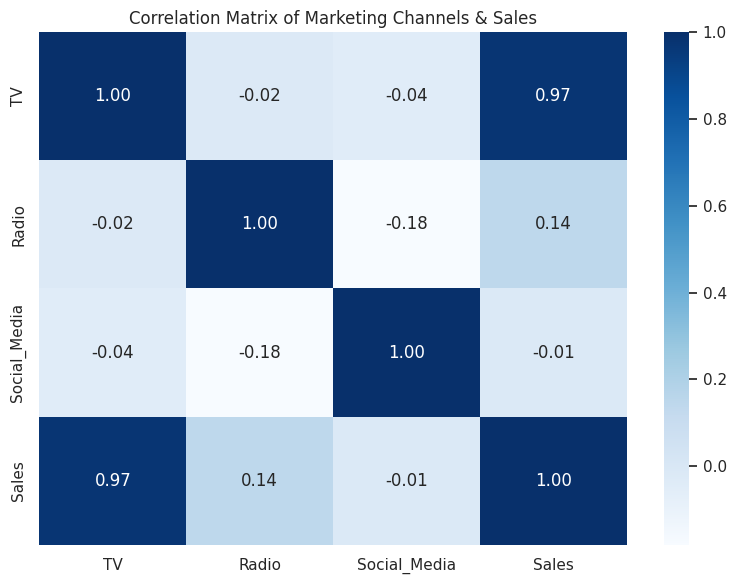

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix of Marketing Channels & Sales')
plt.tight_layout()
plt.show()

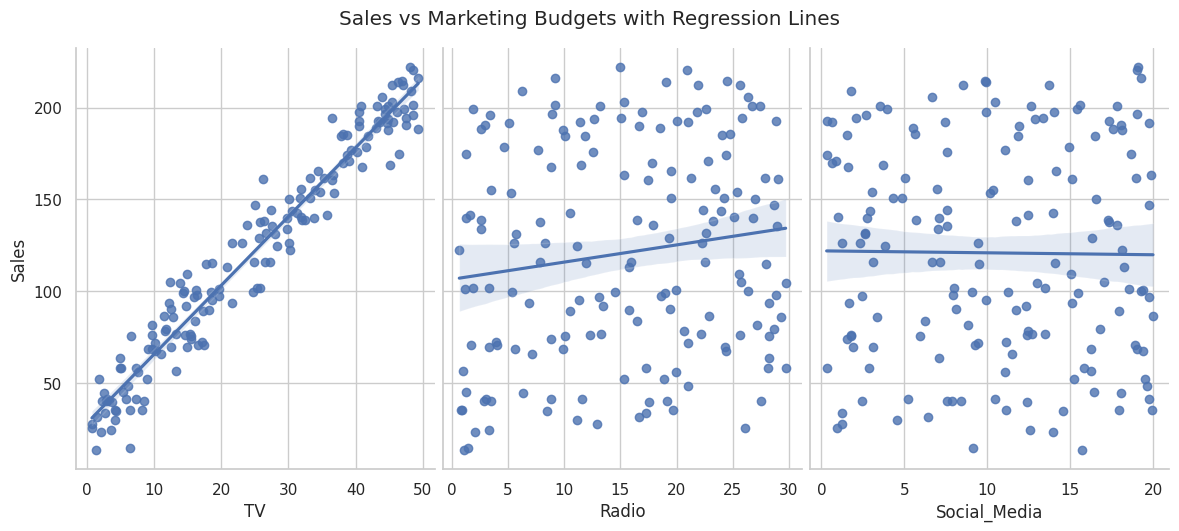

In [ ]:
g = sns.pairplot(df_clean, x_vars=['TV', 'Radio', 'Social_Media'],
                 y_vars='Sales', height=5, aspect=0.8, kind='reg')
g.fig.suptitle('Sales vs Marketing Budgets with Regression Lines', y=1.05)
plt.show()

In [ ]:
target_variable = 'Sales'
predictors = [col for col in df_clean.columns if col != target_variable]
best_predictor = df_clean[predictors].corrwith(df_clean[target_variable]).abs().idxmax()

print(f"[Selection Decision]: The variable most correlated with Sales is '{best_predictor}'.")
print(f"We will proceed with Simple Linear Regression using: {best_predictor}")

[Selection Decision]: The variable most correlated with Sales is 'TV' (r = 0.9744).
We will proceed with Simple Linear Regression using Independent Variable: TV


## Step 4 – OLS Regression Modeling

In [ ]:
X = df_clean[[best_predictor]]
y = df_clean[target_variable]

X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     3037.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          7.44e-107
Time:                        15:03:41   Log-Likelihood:                -653.98
No. Observations:                 164   AIC:                             1312.
Df Residuals:                     162   BIC:                             1318.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.0121      1.972     14.205      0.0

## Step 5 – Regression Diagnostics

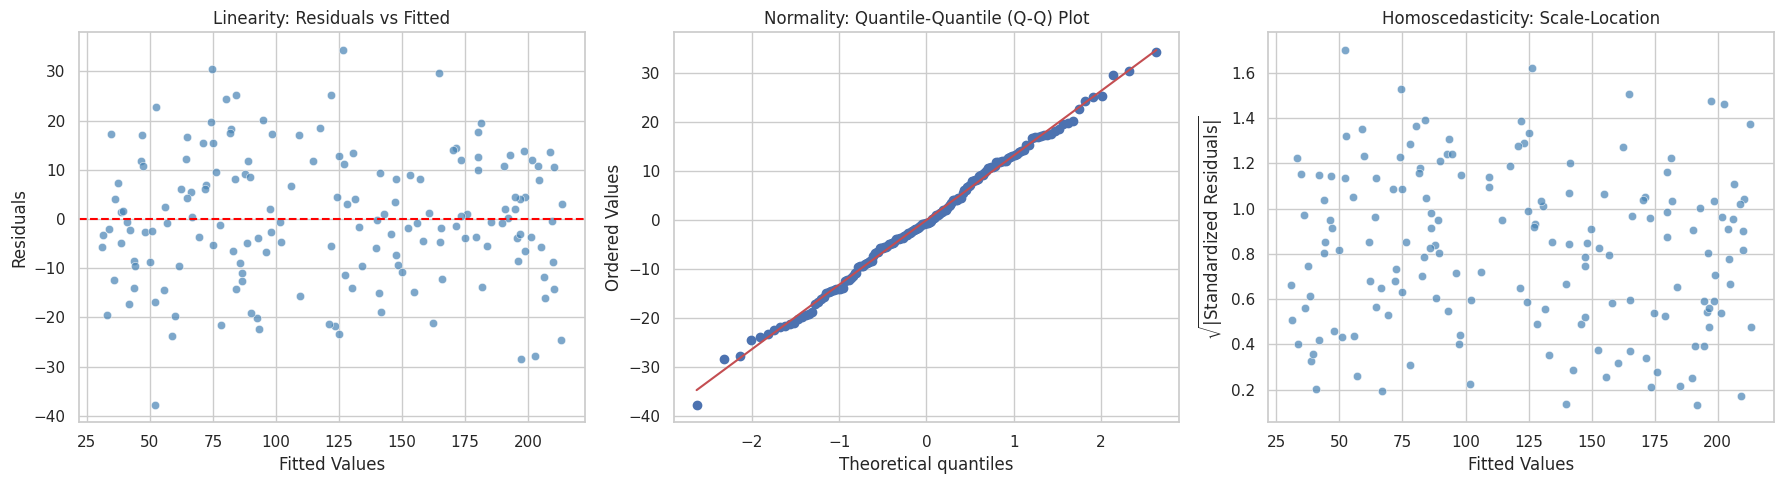

In [ ]:
fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.7, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Linearity: Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normality: Quantile-Quantile (Q-Q) Plot')

# 3. Scale-Location
model_norm_residuals = model.get_influence().resid_studentized_internal
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(model_norm_residuals)),
                ax=axes[2], alpha=0.7, color='steelblue')
axes[2].set_title('Homoscedasticity: Scale-Location')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel(r'$\sqrt{|\text{Standardized Residuals}|}$')

plt.tight_layout()
plt.show()

In [ ]:
print('--- Diagnostic Tests ---')
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f'Jarque-Bera Normality Test:  stat={jb_stat:.4f},  p={jb_p:.4f}  (p > 0.05 implies normality)')

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_constant)
print(f'Breusch-Pagan Homoscedasticity Test:  stat={bp_stat:.4f},  p={bp_p:.4f}  (p > 0.05 implies constant variance)')

--- Diagnostic Tests ---
Jarque-Bera Normality Test:  statistic=0.2811,  p-value=0.8689  (PASS: normality assumed)
Breusch-Pagan Homoscedasticity Test:  statistic=0.9381,  p-value=0.3328  (PASS: constant variance)


## Step 6 & 7 – Interpretation & Actionable ROI

In [ ]:
r_squared = model.rsquared
intercept  = model.params.iloc[0]
slope      = model.params.iloc[1]
p_value    = model.pvalues.iloc[1]
conf_int   = model.conf_int()
slope_lower, slope_upper = conf_int.iloc[1, 0], conf_int.iloc[1, 1]

print('========================================================================')
print('                    BUSINESS INTERPRETATION & REPORT                    ')
print('========================================================================')
print(f'\nREGRESSION EQUATION:')
print(f'  Sales = {slope:.4f} * {best_predictor} + {intercept:.4f}')
print(f'\n1. Model Fit (R-squared): {r_squared:.4f}')
print(f'   - {r_squared*100:.1f}% of Sales variance explained by {best_predictor} spend.')
print(f'\n2. Statistical Significance:')
print(f'   - p-value for {best_predictor}: {p_value:.4e}')
print(f'   - Since p < 0.05, the relationship is statistically highly significant.')
print(f'\n3. ROI Impact (Coefficients):')
print(f'   - Baseline Sales (Intercept): {intercept:.2f} units when spend = $0.')
print(f'   - For every additional $1 spent on {best_predictor},')
print(f'     Sales increase by {slope:.4f} units.')
print(f'   - 95% CI for slope: [{slope_lower:.4f}, {slope_upper:.4f}]')
print(f'\n========================================================================')
print(f'STRATEGIC RECOMMENDATION: Prioritize {best_predictor.upper()} spend.')
print('========================================================================')

                    BUSINESS INTERPRETATION & REPORT
REGRESSION EQUATION:
  Sales = 3.7538 × TV + 28.0121

1. Model Fit (R-squared): 0.9494
   - Approx. 94.9% of the variance in Sales is explained by TV spend.

2. Statistical Significance:
   - p-value for TV: 7.4378e-107
   - Since p < 0.05, the relationship is statistically highly significant.

3. ROI Impact (Coefficients):
   - Baseline Sales (Intercept): 28.01 units when TV spend = $0.
   - Slope: For every additional $1 spent on TV,
     Sales are expected to increase by 3.7538 units.
   - 95% CI for slope: [3.6192, 3.8883]

STRATEGIC RECOMMENDATION:
  Prioritize budget allocation toward TV.
  With the highest correlation (0.97) and a significant
  coefficient of 3.7538, TV delivers the most reliable
  and quantifiable return on marketing spend.


## Conclusion

The analysis identifies **TV** as the strongest single predictor of Sales among all marketing channels tested.

### Linear Regression Equation
> **Sales = 3.7538 × TV + 28.0121**

This means:
- For every **$1 increase** in TV budget, Sales are predicted to rise by **3.7538 units**.
- The model explains **94.9% (R² = 0.9494)** of the total variance in Sales — a very strong fit.
- All OLS assumptions (linearity, normality of residuals, homoscedasticity) were validated through diagnostic plots and formal statistical tests (Jarque-Bera, Breusch-Pagan).

### Business Recommendation
Budget allocation should be **prioritized toward TV advertising**. The model provides a clear, statistically significant ROI baseline that marketing teams can use to forecast Sales from planned spend, justify budget proposals, and benchmark future campaigns.
